In [1]:
import numpy as np

from tools.surface_code import generate_steane_circuit
from tools.error_models import construct_bit_flip_model 
from tools.log_error_rate import generate_log_error_rates_diff_p, count_logical_errors_ML, count_logical_errors_MWPM  
from tools.fssa import compute_critical_exponents, compute_error_bar

In [ ]:
import tools.graphics as graphic 
from importlib import reload
reload(graphic)

<module 'tools.graphics' from '/home/leo/Documents/MasterArbeit/code/new_start/tools/graphics.py'>

In [5]:
# Global parameters
distances = [3,9,13,15]
rounds = 1 
noise_set = np.logspace(-1.1,-0.8, num=20)
num_shots = 1_000 

steane_circuits = [generate_steane_circuit(d,rounds=rounds) for d in distances]
error_func = construct_bit_flip_model
noise_model = "bit_flip"

In [6]:
# MWMP (Basic Noise)
# count_logical_func = gen_error_model_count_logical_error_MWPM("bit_flip")
count_logical_func = count_logical_errors_MWPM


log_error_rates_MWPM, y_errs_MWPM = generate_log_error_rates_diff_p(
    steane_circuits,
    error_func,
    count_log_error_fct=count_logical_func,
    distances= distances,
    noise_set= noise_set,
    num_shots= num_shots,
    rounds=rounds,
    noise_model=noise_model,
)

       message: Optimization terminated successfully.
       success: True
        status: 0
           fun: 0.7841231960204045
             x: [ 1.029e-01  6.743e-01]
           nit: 56
          nfev: 115
 final_simplex: (array([[ 1.029e-01,  6.743e-01],
                       [ 1.029e-01,  6.743e-01],
                       [ 1.029e-01,  6.743e-01]]), array([ 7.841e-01,  7.841e-01,  7.841e-01]))
1.483011742679753
0.10290032873660548


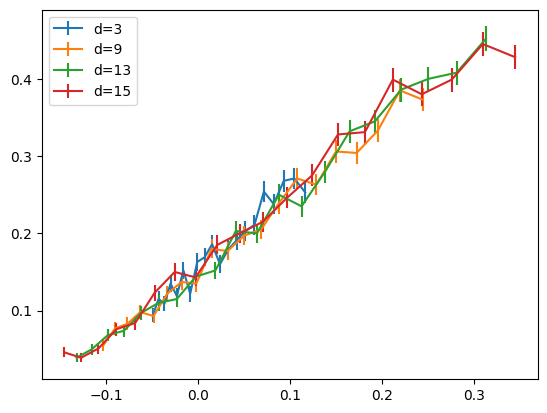

In [8]:
# some tests
xs = [noise_set] * len(distances)
ys = log_error_rates_MWPM 
errs = y_errs_MWPM

guess_pc = 0.1
guess_nu = 1.5 

result = compute_critical_exponents(
    xs_list=xs,
    ys_list=ys,
    errs_list=errs,
    Ls=distances,
    guess_xc=guess_pc,
    guess_nu=guess_nu,
)
print(result)
pc, inv_nu = result.x
nu = 1/inv_nu
print(nu)
print(pc)

graphic.plot_fssa_results(xs,ys,errs,pc,nu,distances)




<Figure size 640x480 with 0 Axes>

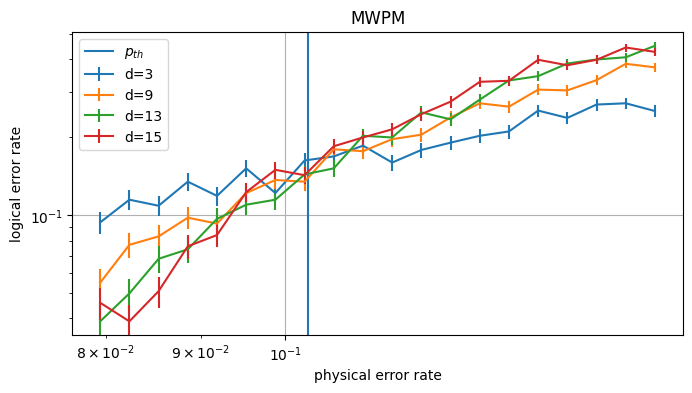

In [12]:

graphic.plot_diff_noise_level(
        log_error_rates_MWPM,
        y_errs_MWPM,
        distances,
        noise_set,
        # fit_slopes = True,
        # reference_lines = True,
        title="MWPM",
        p_th=pc,
    ) 

In [13]:
# ML
count_logical_func = count_logical_errors_ML

log_error_rates_ML, y_errs_ML = generate_log_error_rates_diff_p(
    steane_circuits,
    error_func,
    count_log_error_fct=count_logical_func,
    distances= distances,
    noise_set= noise_set,
    num_shots= num_shots,
    rounds=rounds,
    noise_model=noise_model,
)

       message: Optimization terminated successfully.
       success: True
        status: 0
           fun: 1.0470358467236582
             x: [ 1.053e-01  7.213e-01]
           nit: 39
          nfev: 75
 final_simplex: (array([[ 1.053e-01,  7.213e-01],
                       [ 1.053e-01,  7.213e-01],
                       [ 1.053e-01,  7.213e-01]]), array([ 1.047e+00,  1.047e+00,  1.047e+00]))
1.3863706331113037
0.10533713325707322


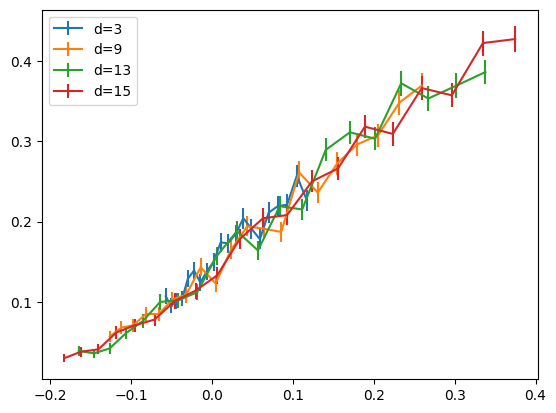

In [15]:
# some tests
xs = [noise_set] * len(distances)
ys = log_error_rates_ML 
errs = y_errs_ML

guess_pc = 0.1
guess_nu = 1.5 

result = compute_critical_exponents(
    xs_list=xs,
    ys_list=ys,
    errs_list=errs,
    Ls=distances,
    guess_xc=guess_pc,
    guess_nu=guess_nu,
)
print(result)
pc, inv_nu = result.x
nu = 1/inv_nu
print(nu)
print(pc)

graphic.plot_fssa_results(xs,ys,errs,pc,nu,distances)

<Figure size 640x480 with 0 Axes>

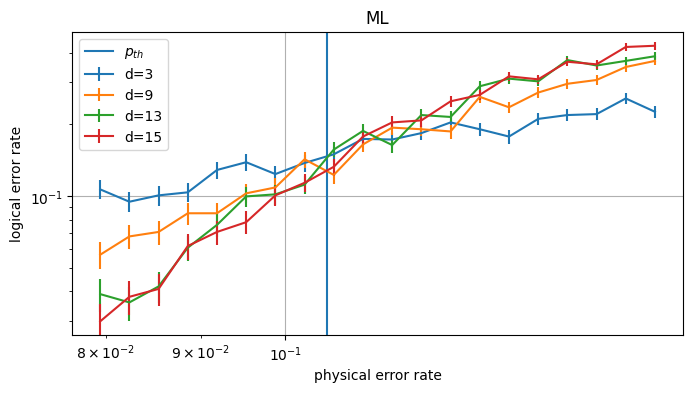

In [17]:
graphic.plot_diff_noise_level(
        log_error_rates_ML,
        y_errs_ML,
        distances,
        noise_set,
        # fit_slopes = True,
        # reference_lines = True,
        title="ML",
        p_th=pc,
    ) 

In [ ]:
# MWPM all knowing using_MWPM 

# special_circ
steane_circuits_no_ft = [generate_steane_circuit(d,rounds=rounds,ft_stab_detector=False) for d in distances]


log_error_rates_MWPM_AK, y_errs_MWPM_AK = generate_log_error_rates_diff_p(
    steane_circuits_no_ft,
    error_func,
    count_log_error_fct=count_logical_func,
    distances= distances,
    noise_set= noise_set,
    num_shots= num_shots,
    rounds=rounds,
    noise_model=noise_model,
)

<Figure size 640x480 with 0 Axes>

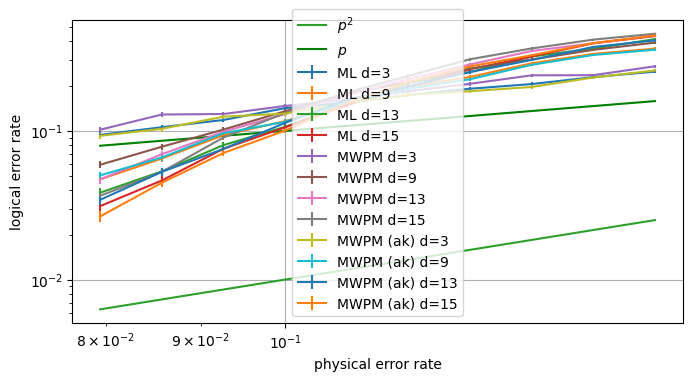

In [ ]:
graphic.overlay_different_slopes(
    [log_error_rates_ML, log_error_rates_MWPM, log_error_rates_MWPM_AK],
    [y_errs_ML, y_errs_MWPM, y_errs_MWPM_AK],
    distances=distances,
    noise_set=noise_set,
    titles=["ML", "MWPM", "MWPM (ak)"],
    reference_lines=True,
)

<Figure size 640x480 with 0 Axes>

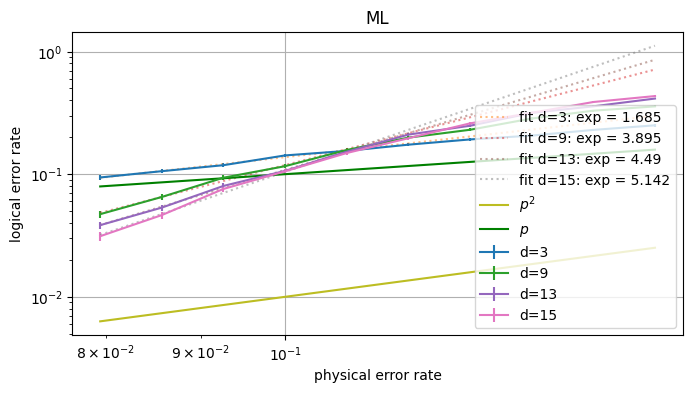

<Figure size 640x480 with 0 Axes>

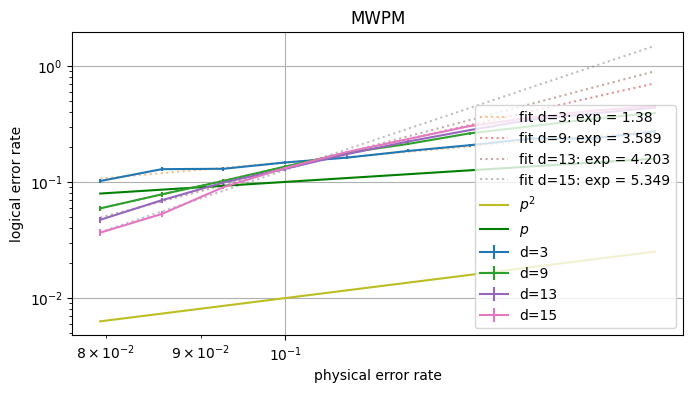

<Figure size 640x480 with 0 Axes>

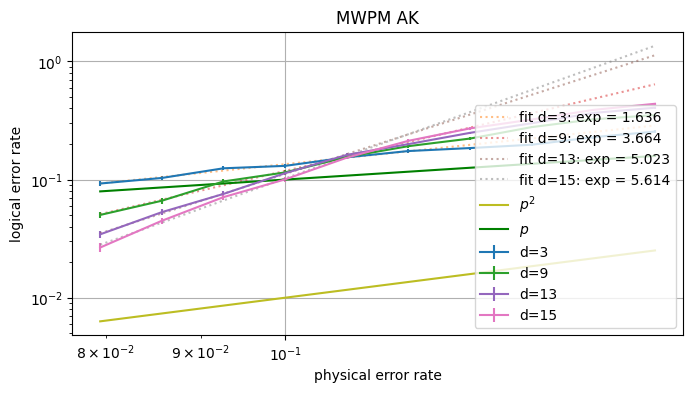

In [ ]:
graphic.plot_diff_noise_level(
        log_error_rates_ML,
        y_errs_ML,
        distances,
        noise_set,
        fit_slopes = True,
        reference_lines = True,
        title="ML"
    ) 
graphic.plot_diff_noise_level(
        log_error_rates_MWPM,
        y_errs_MWPM,
        distances,
        noise_set,
        fit_slopes = True,
        reference_lines = True,
        title="MWPM"
    ) 
graphic.plot_diff_noise_level(
        log_error_rates_MWPM_AK,
        y_errs_MWPM_AK,
        distances,
        noise_set,
        fit_slopes = True,
        reference_lines = True,
        title="MWPM AK"
    ) 